In [1]:
import pandas as pd 
from sklearn.preprocessing import RobustScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Copia de data_merged.csv")

In [3]:

def aux(temp):
    if temp<=80:
        return 'lento'
    elif temp <=120:
        return 'moderado'
    return 'rapido'

df['duration_ms']= df['duration_ms']/60000
df['duration_ms_ar'] = df['duration_ms_ar']/60000
df['duration_ms_yr'] = df['duration_ms_yr']/60000

df['energy_ratio_yr'] = df['energy_yr']*df['acousticness_yr']
df['electro_focus_yr'] = (1-df['acousticness_yr'])*df['energy_yr']*df['instrumentalness_yr']
df['vocal_energy_yr'] = (1-df['instrumentalness_yr'])*df['energy_yr']

df['energy_ratio_'] = df['energy']*df['acousticness']
df['electro_focus'] = (1-df['acousticness'])*df['energy']*df['instrumentalness']
df['vocal_energy'] = (1-df['instrumentalness'])*df['energy']

df['energy_ratio_ar'] = df['energy_ar']*df['acousticness_ar']
df['electro_focus_ar'] = (1-df['acousticness_ar'])*df['energy_ar']*df['instrumentalness_ar']
df['vocal_energy_ar'] = (1-df['instrumentalness_ar'])*df['energy_ar']


df['temp_range'] = df['tempo_yr'].apply(aux)
df = pd.get_dummies(df,columns=['temp_range'],prefix='temp')
df[['temp_moderado','temp_rapido']] = df[['temp_moderado','temp_rapido']].astype(int)

In [4]:
df.head()

,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,liveness,loudness,popularity,speechiness,...,electro_focus_yr,vocal_energy_yr,energy_ratio_,electro_focus,vocal_energy,energy_ratio_ar,electro_focus_ar,vocal_energy_ar,temp_moderado,temp_rapido
0,0.0131,0.2560,3.039117,0.895,0,0.000106,0.0821,-4.860,29,0.0707,...,0.037649,0.495522,0.011725,0.000094,0.894905,0.105519,1.463051e-02,0.709725,0,1
1,0.9800,0.2770,3.449533,0.145,0,0.879000,0.1110,-19.898,0,0.0845,...,0.009108,0.183282,0.142100,0.002549,0.017545,0.208915,4.504740e-03,0.097838,1,0
2,0.7950,0.6850,5.244450,0.483,0,0.878000,0.1130,-10.202,1,0.0337,...,0.010180,0.186780,0.383985,0.086935,0.058926,0.491828,6.804020e-02,0.059278,1,0
3,0.6560,0.7880,2.995783,0.808,0,0.000000,0.1540,-6.590,0,0.0395,...,0.010180,0.186780,0.530048,0.000000,0.808000,0.537642,2.723306e-07,0.744999,1,0
4,0.3020,0.0753,8.309333,0.150,0,0.884000,0.1210,-16.705,0,0.0371,...,0.007777,0.179243,0.045300,0.092555,0.017400,0.253033,3.753181e-02,0.103445,1,0


In [5]:

df_processed = df.copy()

initial_rows = len(df_processed)
df_processed = df_processed.dropna()

def categorize_popularity(popularity):
    if popularity<=20:
        return 0 # baja
    elif popularity <=45:
        return 1 # media
    return 2 # alta
    

df_processed['popularity_multiclass'] = df_processed['popularity'].apply(categorize_popularity)
print("\nVariable multiclase 3 niveles (popularity_multiclass):")
multiclass_counts = df_processed['popularity_multiclass'].value_counts().sort_index()
multiclass_labels = ['Baja', 'Media', 'Alta']
for i, (count, label) in enumerate(zip(multiclass_counts, multiclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")




Variable multiclase 3 niveles (popularity_multiclass):
   0 (Baja): 73762 (42.8%)
   1 (Media): 62074 (36.0%)
   2 (Alta): 36394 (21.1%)


In [6]:
scaler = RobustScaler()
_X = df_processed.copy()

X = _X.drop(columns=['popularity','popularity_multiclass'])
y_multiclass_3 = df_processed['popularity_multiclass'] 

In [7]:
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif,k=6)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select


array(['popularity_ar', 'acousticness_yr', 'energy_yr',
       'instrumentalness_yr', 'popularity_yr', 'vocal_energy_yr'],
      dtype=object)

In [8]:
_X = X.copy()
y = y_multiclass_3
scaler = RobustScaler()
from sklearn.model_selection import train_test_split
X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)

_X = scaler.fit_transform(X_train_reduce)

In [9]:

tsne = TSNE(n_components=2,random_state=42)
X_tsne  = tsne.fit_transform(_X)


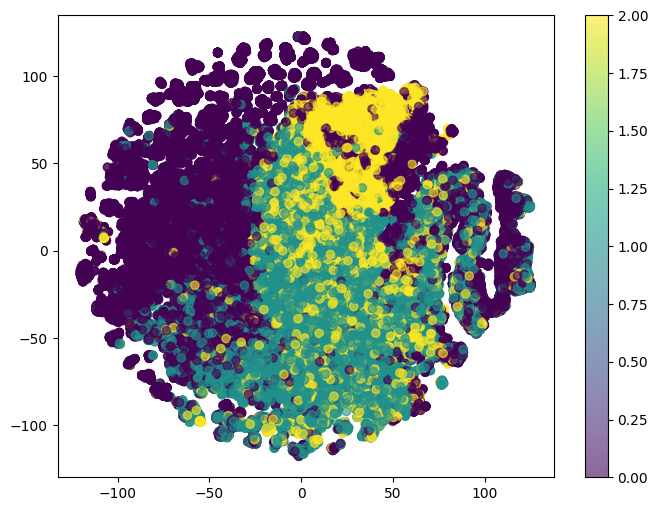

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0],X_tsne[:,1],c=y_train_reduce,cmap='viridis',alpha=0.6)
plt.colorbar()
plt.show()